In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/global_power_plant_database.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

/tmp/ipykernel_934/2510385826.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [2]:
# Identify missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0
other_fuel1,32992
other_fuel2,34660
other_fuel3,34844
commissioning_year,17489
owner,14068
source,15
url,18
geolocation_source,419
wepp_id,18702
year_of_capacity_data,20049


In [3]:
# Fill 'other_fuel' columns with 'None'
for col in ['other_fuel1', 'other_fuel2', 'other_fuel3']:
    df[col] = df[col].fillna('None')

# Convert 'commissioning_year' to numeric, coercing errors, then fill with median
df['commissioning_year'] = pd.to_numeric(df['commissioning_year'], errors='coerce')
median_commissioning_year = df['commissioning_year'].median()
df['commissioning_year'] = df['commissioning_year'].fillna(median_commissioning_year)

# Fill 'generation_gwh' and 'estimated_generation_gwh' columns with 0
gen_cols = [col for col in df.columns if 'generation_gwh' in col]
for col in gen_cols:
    df[col] = df[col].fillna(0)

# Fill other selected columns with 'Unknown' or 0
df['owner'] = df['owner'].fillna('Unknown')
df['source'] = df['source'].fillna('Unknown')
df['url'] = df['url'].fillna('Unknown')
df['geolocation_source'] = df['geolocation_source'].fillna('Unknown')
df['wepp_id'] = df['wepp_id'].fillna('Unknown')
df['year_of_capacity_data'] = df['year_of_capacity_data'].fillna(0) # Assuming 0 if year is unknown

# Display remaining missing values to confirm cleanup
remaining_missing_values = df.isnull().sum()
display(remaining_missing_values[remaining_missing_values > 0])

,0
generation_data_source,23536


In [4]:
# Fill remaining missing values in 'generation_data_source' with 'Unknown'
df['generation_data_source'] = df['generation_data_source'].fillna('Unknown')

# Confirm no more missing values
remaining_missing_values_final = df.isnull().sum()
display(remaining_missing_values_final[remaining_missing_values_final > 0])

# Now, let's look at key statistics for numerical columns
display(df.describe())

,0


,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000
mean,163.355148,32.816637,-6.972803,2002.213173,860.007557,108.865666,135.862677,179.004797,181.422070,179.969788,142.701523,117.204798,110.330003,114.519144,115.110958,118.535774,679.571235
std,489.636072,22.638603,78.405850,17.215166,998.048133,959.867513,1049.093115,1269.384526,1267.279351,1270.071080,1062.866856,912.965076,817.911666,891.961731,892.928446,900.967741,2424.758039
min,1.000000,-77.847000,-179.977700,1896.000000,0.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.900000,29.256475,-77.641550,2007.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.820000
50%,16.745000,39.727750,-2.127100,2007.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.330000,32.475000
75%,75.344250,46.263125,49.502675,2007.000000,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.114250,21.592500,23.492500,24.720000,28.040000,195.640000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [5]:
# Explore the distribution of power plants by country
print("\nTop 10 Countries by Number of Power Plants:")
display(df['country_long'].value_counts().head(10))

# Explore the distribution of power plants by primary fuel type
print("\nDistribution of Power Plants by Primary Fuel Type:")
display(df['primary_fuel'].value_counts())


Top 10 Countries by Number of Power Plants:


,count
country_long,
United States of America,9833
China,4235
United Kingdom,2751
Brazil,2360
France,2155
India,1589
Germany,1309
Canada,1159
Spain,829



Distribution of Power Plants by Primary Fuel Type:


,count
primary_fuel,
Solar,10665
Hydro,7156
Wind,5344
Gas,3998
Coal,2330
Oil,2320
Biomass,1430
Waste,1068
Nuclear,195


In [6]:
import numpy as np

# Group by primary_fuel and calculate statistical measures for 'capacity_mw'
fuel_capacity_stats = df.groupby('primary_fuel')['capacity_mw'].agg(['mean', 'median', 'std'])

print("\nStatistical Analysis of Power Output (capacity_mw) by Primary Fuel Type:")
display(fuel_capacity_stats.sort_values(by='mean', ascending=False))


Statistical Analysis of Power Output (capacity_mw) by Primary Fuel Type:


,mean,median,std
primary_fuel,,,
Nuclear,2091.855179,1888.00000,1303.509273
Coal,843.579828,600.00000,888.187187
Gas,373.449375,147.50000,560.934146
Petcoke,202.048125,65.48875,476.986459
Hydro,147.171551,20.00000,549.809328
Oil,112.878754,9.00000,392.009039
Cogeneration,98.731707,31.90000,283.428252
Other,84.020000,40.00000,145.891392
Geothermal,67.130952,30.00000,114.640890


In [7]:
from scipy import stats

# Prepare data for ANOVA test
# Create a list of capacity_mw for each primary_fuel type
fuel_types = df['primary_fuel'].unique()
anova_data = [df['capacity_mw'][df['primary_fuel'] == ft] for ft in fuel_types]

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*anova_data)

print(f"\nANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3e}")

if p_value < 0.05:
    print("\nConclusion: The p-value is less than 0.05, which means we reject the null hypothesis.\nThere is a statistically significant difference in the average power output (capacity_mw) among different primary fuel types.")
else:
    print("\nConclusion: The p-value is greater than 0.05, which means we fail to reject the null hypothesis.\nThere is no statistically significant difference in the average power output (capacity_mw) among different primary fuel types.")


ANOVA F-statistic: 967.46
ANOVA P-value: 0.000e+00

Conclusion: The p-value is less than 0.05, which means we reject the null hypothesis.
There is a statistically significant difference in the average power output (capacity_mw) among different primary fuel types.


In [8]:
# Analyze trends over time: Fuel type composition by commissioning year

# Group by commissioning_year and primary_fuel, then count occurrences
fuel_composition_over_time = df.groupby(['commissioning_year', 'primary_fuel']).size().unstack(fill_value=0)

# Display the head and tail of the result to see the trend
print("\nFuel Type Composition by Commissioning Year (Head):")
display(fuel_composition_over_time.head())

print("\nFuel Type Composition by Commissioning Year (Tail):")
display(fuel_composition_over_time.tail())


Fuel Type Composition by Commissioning Year (Head):


primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,
1896.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1899.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1900.0,0,0,0,1,0,3,0,2,0,0,0,0,0,0,0
1901.0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
1902.0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0



Fuel Type Composition by Commissioning Year (Tail):


primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,
2019.000000,2,0,1,34,2,1,0,2,0,0,458,32,3,0,61
2019.000000,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2019.411765,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2019.796326,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2020.000000,1,0,0,6,0,0,0,0,0,0,122,2,2,0,17


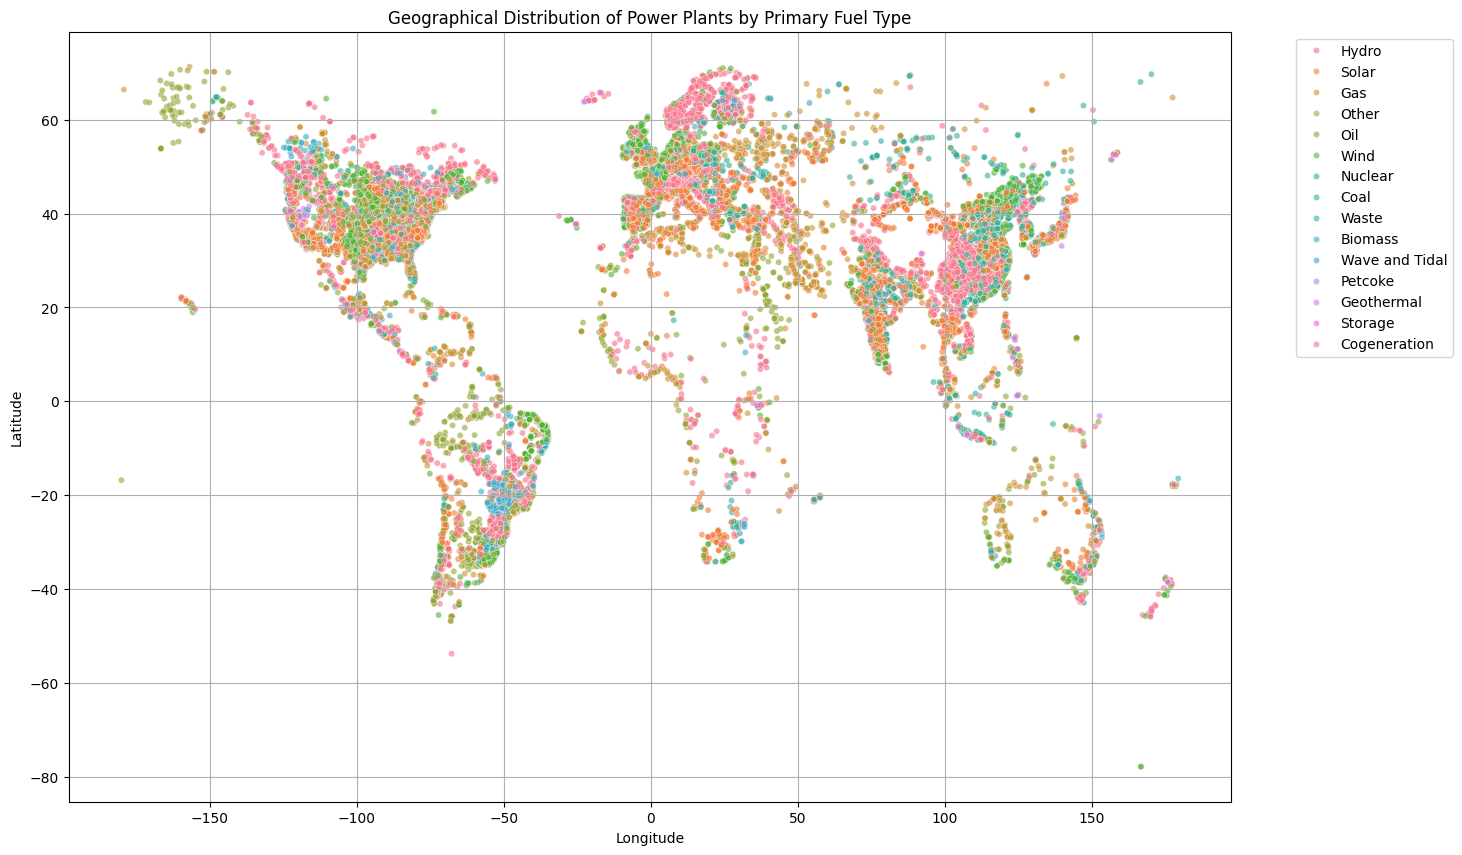

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot for geographical distribution of power plants
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='primary_fuel', s=20, alpha=0.6)
plt.title('Geographical Distribution of Power Plants by Primary Fuel Type')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


Correlation Matrix of Selected Numerical Attributes:


,capacity_mw,latitude,longitude,commissioning_year,generation_gwh_2017,estimated_generation_gwh_2017
capacity_mw,1.000000,-0.013218,0.151525,-0.041883,0.406642,0.946238
latitude,-0.013218,1.000000,-0.068354,-0.076600,0.014206,-0.013265
longitude,0.151525,-0.068354,1.000000,0.114576,-0.043676,0.145158
commissioning_year,-0.041883,-0.076600,0.114576,1.000000,-0.065944,-0.033549
generation_gwh_2017,0.406642,0.014206,-0.043676,-0.065944,1.000000,0.459947
estimated_generation_gwh_2017,0.946238,-0.013265,0.145158,-0.033549,0.459947,1.000000


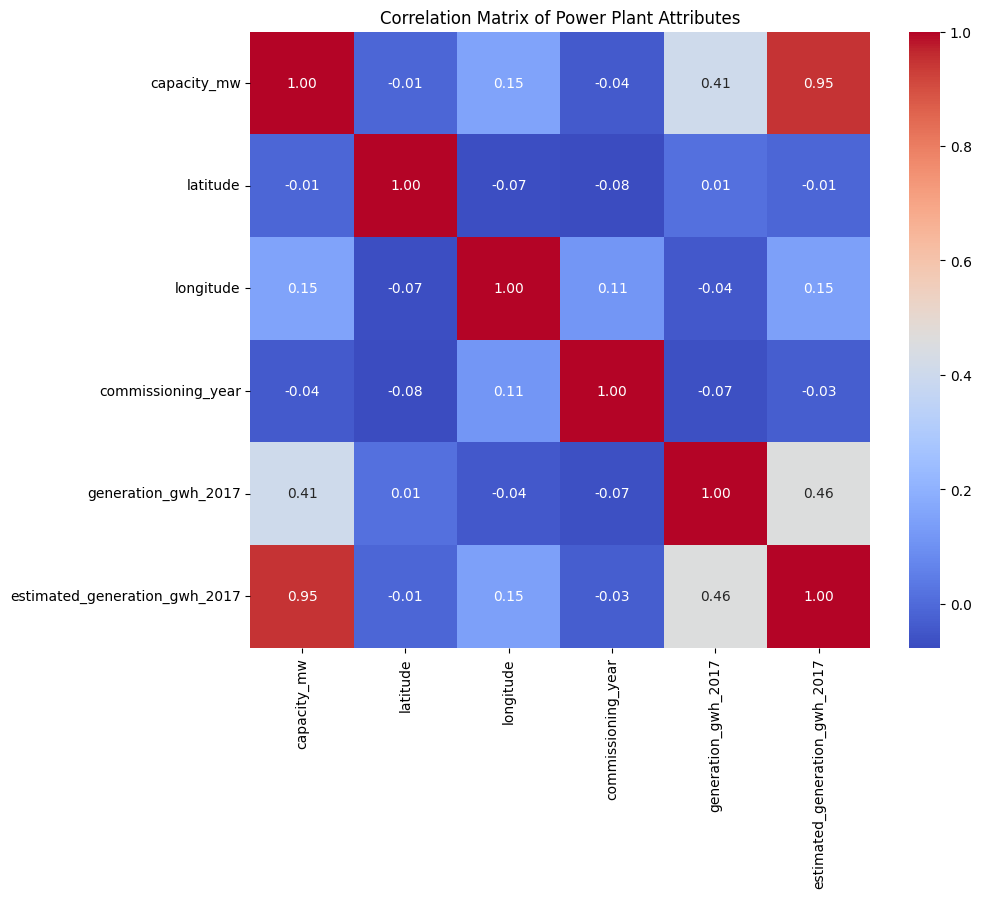

In [10]:
# Demonstrate Matrix Operations: Correlation Matrix

# Select relevant numerical columns for correlation analysis
correlation_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year',
                    'generation_gwh_2017', 'estimated_generation_gwh_2017']

# Create a sub-DataFrame with these columns and calculate the correlation matrix
correlation_matrix = df[correlation_cols].corr()

print("\nCorrelation Matrix of Selected Numerical Attributes:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap for better readability
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Power Plant Attributes')
plt.show()